In [14]:
# Instalando os pacotes das bibliotecas
import pandas as pd
import numpy as np
import joblib
import os
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    roc_auc_score,
    roc_curve,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score
)

[Otimização] Executando RandomizedSearchCV...
Fitting 5 folds for each of 20 candidates, totalling 100 fits

 Melhores Parâmetros Encontrados:
 - n_estimators: 100
 - min_samples_split: 5
 - min_samples_leaf: 4
 - max_features: sqrt
 - max_depth: 5
 - class_weight: balanced_subsample

Melhor AUC-ROC na Validação Cruzada: 0.6231

=== METRICAS NO TESTE (MODELO OTIMIZADO) ===
Acurácia:  0.5642
AUC-ROC:   0.6257
F1-Score:  0.5397
Precisão:  0.4291
Recall:    0.7273

Relatório de Classificação Detalhado:
              precision    recall  f1-score   support

           0       0.76      0.48      0.59       914
           1       0.43      0.73      0.54       495

    accuracy                           0.56      1409
   macro avg       0.60      0.60      0.56      1409
weighted avg       0.65      0.56      0.57      1409



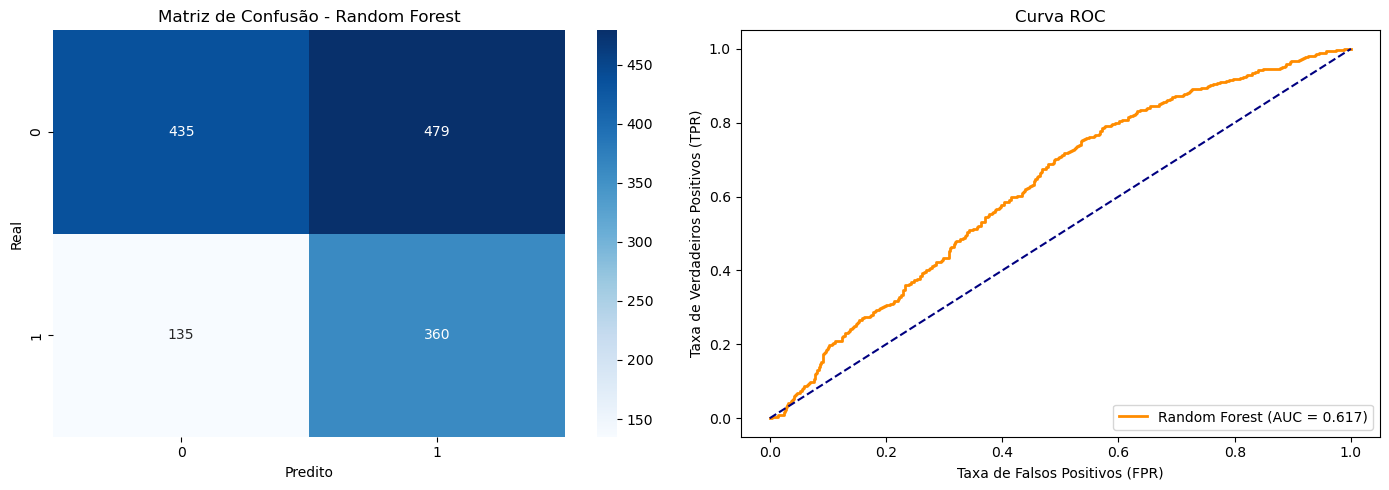

C:\Users\eduardo.sepulveda\AppData\Local\Temp\ipykernel_29296\2090672272.py:86: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_10.values, y=top_10.index, palette='viridis')


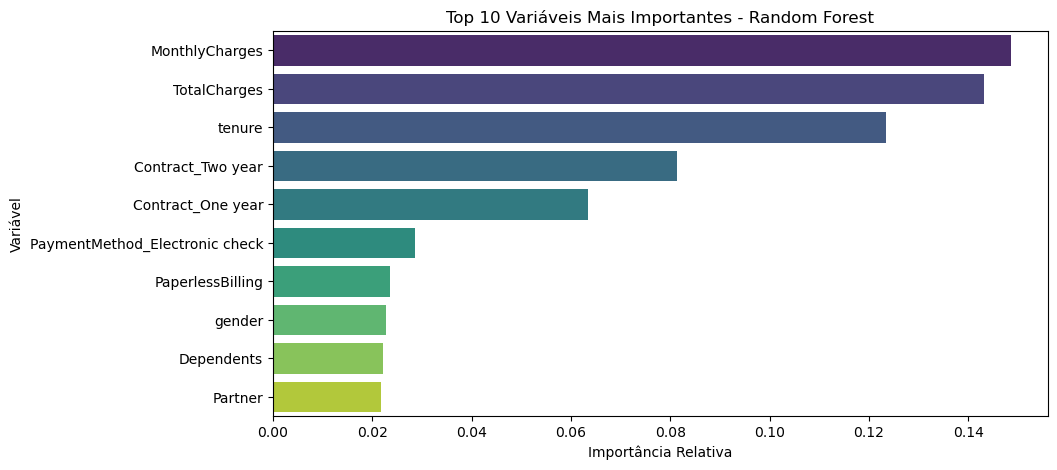

Modelo otimizado salvo em: ../models/random_forest_tuned.joblib


In [17]:
# 1. Carregar os dados processados
X_train = pd.read_csv('../data/processed/X_train.csv')
X_test = pd.read_csv('../data/processed/X_test.csv')
y_train = pd.read_csv('../data/processed/y_train.csv').squeeze()
y_test = pd.read_csv('../data/processed/y_test.csv').squeeze()

# 2. Definir o espaço de busca de hiperparâmetros
param_dist = {
    'n_estimators': [100, 200, 300],          # Número de árvores
    'max_depth': [5, 10, 15, 20, None],       # Profundidade máxima
    'min_samples_split': [2, 5, 10],          # Mínimo de amostras para dividir nó
    'min_samples_leaf': [1, 2, 4],            # Mínimo de amostras na folha
    'max_features': ['sqrt', 'log2', None],   # Número de features consideradas por divisão
    'class_weight': ['balanced', 'balanced_subsample'] # Estratégia de balanceamento
}

# 3. Instanciar o modelo base
rf_base = RandomForestClassifier(random_state=42)

# 4. Configurar a busca aleatória com Validação Cruzada (5 folds)
random_search = RandomizedSearchCV(
    estimator=rf_base,
    param_distributions=param_dist,
    n_iter=20,                # Testa 20 combinações aleatórias
    scoring='roc_auc',         # Métrica otimizada (AUC-ROC)
    cv=5,                      # 5-fold Stratified Cross-Validation
    random_state=42,
    n_jobs=-1,                 # Utiliza todos os núcleos da CPU
    verbose=1
)

print("[Otimização] Executando RandomizedSearchCV...")
random_search.fit(X_train, y_train)

# 5. Exibir os melhores parâmetros encontrados
print("\n Melhores Parâmetros Encontrados:")
for param, val in random_search.best_params_.items():
    print(f" - {param}: {val}")

print(f"\nMelhor AUC-ROC na Validação Cruzada: {random_search.best_score_:.4f}")

# 6. Avaliar o melhor modelo no conjunto de TESTE
best_rf = random_search.best_estimator_

y_pred = best_rf.predict(X_test)
y_prob = best_rf.predict_proba(X_test)[:, 1]

print("\n=== METRICAS NO TESTE (MODELO OTIMIZADO) ===")
print(f"Acurácia:  {accuracy_score(y_test, y_pred):.4f}")
print(f"AUC-ROC:   {roc_auc_score(y_test, y_prob):.4f}")
print(f"F1-Score:  {f1_score(y_test, y_pred):.4f}")
print(f"Precisão:  {precision_score(y_test, y_pred):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred):.4f}\n")

print("Relatório de Classificação Detalhado:")
print(classification_report(y_test, y_pred))

##entrada de código novo ##
# 4. Matriz de Confusão e Curva ROC
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# Matriz de Confusão
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax[0])
ax[0].set_title('Matriz de Confusão - Random Forest')
ax[0].set_xlabel('Predito')
ax[0].set_ylabel('Real')

# Curva ROC
fpr, tpr, _ = roc_curve(y_test, y_prob)
ax[1].plot(fpr, tpr, label=f'Random Forest (AUC = {auc:.3f})', color='darkorange', lw=2)
ax[1].plot([0, 1], [0, 1], color='navy', linestyle='--')
ax[1].set_xlabel('Taxa de Falsos Positivos (FPR)')
ax[1].set_ylabel('Taxa de Verdadeiros Positivos (TPR)')
ax[1].set_title('Curva ROC')
ax[1].legend(loc='lower right')

plt.tight_layout()
plt.show()

# 5. Importância das Variáveis (Feature Importance)
feature_importances = pd.Series(rf_model.feature_importances_, index=X_train.columns)
top_10 = feature_importances.nlargest(10)

plt.figure(figsize=(10, 5))
sns.barplot(x=top_10.values, y=top_10.index, palette='viridis')
plt.title('Top 10 Variáveis Mais Importantes - Random Forest')
plt.xlabel('Importância Relativa')
plt.ylabel('Variável')
plt.show()

##final do código ###


# 7. Salvar o melhor modelo ajustado
pasta_modelos = '../models/'
os.makedirs(pasta_modelos, exist_ok=True)
caminho_modelo = os.path.join(pasta_modelos, 'random_forest_tuned.joblib')
joblib.dump(best_rf, caminho_modelo)
print(f"Modelo otimizado salvo em: {caminho_modelo}")

#### Comparação direta entre o Random Forest Base (sem otimização) e o Random Forest Otimizado (com RandomizedSerchCV)

Evidencia uma muddança no comportamento da classificação voltada para a estratégia de retenção de clientes.

<center>Tabela Comparativa de Desempenho</center>

| Métrica | Modelo Base | Modelo Otimizado | Variação Absoluta | Variação Relativa |
| ------- | ----------- | ---------------- | ----------------- | ----------------- |
| Recall  |   56,16%    |     72,73%       |    + 16,57%       |      + 29,50%     |
|F1-Score |   0,4916    |     0,5397       |    + 0,0481       |      + 9,78%      |
|AUC-ROC  |   0,6170    |     0,6257       |    + 0,0087       |      + 1,41%      |
|Acurácia |   59,19%    |     56,42%       |    - 2,77%        |      - 4,68%      |
|Precisão |   43,71%    |     42,91%       |    - 0,80%        |      - 1,83%      |

<hr>

#### Análise dos Aspectos Técnico-Comerciais

* <b>Aumento Crítico do Recall (+16,57 p.p. / +29,50%):</b> O modelo otimizado passa a detectar 72,73% de todos os cancelamentos reais (360 de 495 clientes em risco no conjunto de teste), comparado a 56,16% (278 de 495) do modelo base.
* <b>Evolução no $F_1$-Score (+9,78%):</b> O indicador harmônico da classe minoritária subiu de 0,4916 para 0,5397, confirmando que o aumento no volume de detecção superou a variação marginal de precisão.
* <b>Capacidade de Separação (AUC-ROC):</b> A métrica AUC-ROC evoluiu de 0,6170 para 0,6257 (alinhada à validação cruzada de 0,6231), garantindo que a ordenação das probabilidades preditas está mais robusta.
* <b>Impacto no Negócio (Trade-off de Acurácia x Sensibilidade):</b> A acurácia geral caiu de 59,19% para 56,42% devido ao aumento de falsos positivos (clientes ativos classificados com risco de churn). Em telecomunicações, este comportamento é benéfico: o custo de conceder uma ação de retenção a um cliente que não cancelaria é menor do que o custo do cancelamento não detectado (falso negativo).

<hr>

#### Parâmetros Determinantes para a Melhora

* <b>max_depth: 5</b> e <b>min_samples_leaf: 4:</b> Reduziram a profundidade máxima das árvores de decisão, evitando que o algoritmo memorizasse o ruído dos dados de treino.
* <b>class_weight: balanced_subsample:</b> Calibrou a penalidade de erro considerando a proporção das classes em cada amostragem bootstrap, ajustando o ponto de corte do modelo em direção à classe positiva.